
# 270. 컴퓨터 비전(Vision)을 위한 전이학습(Transfer Learning)
=======================================================

- 실제로 충분한 크기의 데이터셋을 갖추기는 상대적으로 드물기 때문에, (무작위 초기화를 통해) 처음부터 합성곱 신경망(Convolutional Network) 전체를 작성하는 경우는 매우 적다.   


- 대신, 매우 큰 데이터셋(예. 100가지 분류에 대해 120만개의 이미지가 포함된 ImageNet)에서 합성곱 신경망(ConvNet)을 미리 학습한 후, 이 합성곱 신경망을 관심있는 작업을 위한 초기 설정 또는 고정된 특징 추출기(fixed feature extractor)로 사용

### 전이학습의 2 가지 시나리오:

-  **합성곱 신경망의 미세조정(finetuning)**: 신경망을 ImageNet 등으로 미리 학습한 신경망으로 초기화하고 parameter 미세 조정  


-  **고정된 특징 추출기로써의 합성곱 신경망**: 마지막 완전 연결층을 제외한 모든 신경망의 가중치를 고정. 마지막의 완전 연결층은 새로운 무작위의 가중치를 갖는 계층으로 대체되어 이 계층만 학습.  

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import resnet18, ResNet18_Weights   # PyTorch 0.13+ 가중치 API
import matplotlib.pyplot as plt
import os
from PIL import Image

WEIGHTS = ResNet18_Weights.IMAGENET1K_V1

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

데이터 불러오기
---------------

- **개미** 와 **벌** 을 분류하는 이진 분류 모델을 학습
    - 대략 120장 정도의 훈련 이미지와, 75장의 검증용 이미지를 이용
    - 전이학습을 통해 소량의 데이터로도 일반화 가능
    - ImageNet의 일부 data 이용

-  데이터를 [여기](https://download.pytorch.org/tutorial/hymenoptera_data.zip)
   에서 다운로드 받아 현재 디렉토리에 압축을 푼다

In [2]:
!wget  https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip -q "hymenoptera_data.zip"

--2026-05-02 09:52:27--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 143.204.160.84, 143.204.160.115, 143.204.160.58, ...
Connecting to download.pytorch.org (download.pytorch.org)|143.204.160.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M  37.8MB/s    in 1.2s    

2026-05-02 09:52:29 (37.8 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]



In [3]:
# 데이터 증강(augmentation) 및 ResNet 에 적합한 normalization 적용
# val 변환은 사전학습 시 사용된 전처리(Resize 256 → CenterCrop 224 → ToTensor → Normalize)를
# WEIGHTS.transforms() 로 그대로 재사용 (PyTorch 0.13+ 신 가중치 API 권장 패턴)
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),        # 이미지를 무작위 크기/비율로 잘라 224x224 로 조정
        transforms.RandomHorizontalFlip(),        # 50% 확률로 수평 반전
        transforms.ToTensor(),                    # PIL → Tensor (값 범위 [0,1])
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet 평균/표준편차로 정규화
    ]),
    # WEIGHTS.transforms() : 사전학습 시 적용된 전처리 파이프라인을 그대로 가져옴
    'val': WEIGHTS.transforms(),
}

# (참고) 어떤 전처리가 들어있는지 출력으로 확인 가능
print("val transform =", data_transforms['val'])


val transform = ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


# ImageFolder 라이브러리

- 계층적인 폴더 구조를 가지고 있는 데이터셋을 불러올 때 사용할 수 있다. 각 이미지들이 자신의 레이블(Label) 이름으로 된 폴더 안에 들어가 있는 구조라면, ImageFolder 라이브러리를 이용하여 이를 바로 불러와 객체로 만들면 된다.

ImageFolder를 사용하기 위해선 가장 먼저 수집된 데이터의 폴더구조를 아래와 같이 설계해야한다  

최상위 경로 아래에 각각의 class name을 가지는 폴더를 구성하고 그 하위경로에 이미지가 저장되어있는 방식이다.
```
root_dir
    | --- ants/
    |      |-- 0001.jpg
    |      |-- 0002.jpg
    |      |-- ...
    | --- bees/
    |      |-- 0001.jpg
    |      |-- 0002.jpg
    |      |-- ...
    | --- rabbit/
    |      |--...
```

In [4]:
data_dir = 'hymenoptera_data'
train_dir = os.path.join(data_dir, 'train')
val_dir  = os.path.join(data_dir, 'val')

print(os.listdir(data_dir))
print(os.listdir(train_dir))
print(os.listdir(val_dir))

['train', 'val']
['bees', 'ants']
['bees', 'ants']


### `datasets.ImageFolder(folder, transform)` data loader 생성

In [5]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),  data_transforms[x])
                                for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4)
                               for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [6]:
print(image_datasets)
print(dataloaders)
print(dataset_sizes)
print(class_names)

{'train': Dataset ImageFolder
    Number of datapoints: 244
    Root location: hymenoptera_data/train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           ), 'val': Dataset ImageFolder
    Number of datapoints: 153
    Root location: hymenoptera_data/val
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )}
{'train': <torch.utils.data.dataloader.DataLoader object at 0x7972905aee40>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x797290822ff0>}
{'train': 244, 'val': 153}
['ants', 'bees']

### 일부 이미지 시각화하기

- `torchvision.utils.make_grid(tensor)`  
  - `tensor (Tensor 또는 list)`: 4차원 텐서 `(B x C x H x W)` 형태의 미니 배치 텐서 또는 같은 크기의 이미지 리스트입니다. (여기서 B는 이미지 개수, C는 채널 수, H와 W는 이미지의 높이와 너비)  
  - `nrow (int, 선택)`: 한 줄에 표시할 이미지 개수입니다. 최종 그리드는 `(B / nrow, nrow)` 형태가 됩니다. 기본값은 8입니다.

In [7]:
def imshow(inp, title=None):
    # 입력 텐서 차원을 재배열. PyTorch - [C, H, W], matplotlib - [H, W, C]
    inp = inp.numpy().transpose(1, 2, 0)

    # 이미지를 정규화할 때 사용된 평균과 표준편차를 정의 - 모델이 학습될 때 사용된 값들
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    # 정규화된 이미지 데이터를 원래의 범위로 되돌립니다.
    inp = inp * std + mean

    # np.clip 함수를 사용하여 이미지 데이터의 값이 0과 1 사이로 제한됩니다.
    inp = np.clip(inp, 0, 1)

    # 이미지 위에 제목 표시
    if title is not None:
        plt.title(title)

    plt.imshow(inp)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


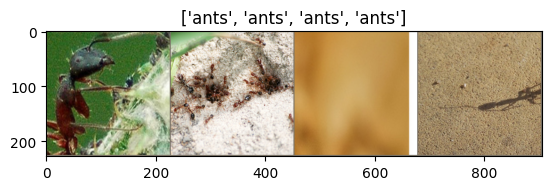

In [8]:
# 훈련 데이터 로더에서 첫 번째 배치를 가져옵니다.
inputs, classes = next(iter(dataloaders['train']))

# 가져온 이미지 배치를 그리드 형태로 만듭니다.
out = torchvision.utils.make_grid(inputs)

# 만들어진 이미지 그리드를 시각화합니다.
imshow(out, title=[class_names[x] for x in classes])

Model Train
--------------

In [9]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    """모델 학습 함수"""
    best_model_path = 'best_model_params.pt'
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        # 훈련 단계
        model.train()
        train_loss = 0.0
        train_correct = 0

        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_loss += loss.item()
            train_correct += torch.sum(preds == labels.data)

        train_loss /= len(dataloaders['train'])
        train_acc = train_correct.double() / dataset_sizes['train']
        scheduler.step()

        # 검증 단계
        model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.inference_mode():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                val_loss += loss.item()
                val_correct += torch.sum(preds == labels.data)

        val_loss /= len(dataloaders['val'])
        val_acc = val_correct.double() / dataset_sizes['val']

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # 최고 성능 모델 저장
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f'새로운 최고 성능! 정확도: {best_acc:.4f}')

    # 최고 성능 모델 로드
    model.load_state_dict(torch.load(best_model_path, weights_only=True))
    print(f'\n학습 완료! 최고 검증 정확도: {best_acc:.4f}')

    return model

모델 예측 시각화

In [10]:
def visualize_model(model, num_images=6):
    """모델의 예측 결과를 시각화"""
    model.eval()

    rows = (num_images + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(10, 3 * rows))
    if rows > 1:
        axes = axes.flatten()
    else:
        axes = axes if isinstance(axes, np.ndarray) else [axes]

    count = 0
    with torch.inference_mode():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)  # labels도 device로 이동
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if count >= num_images:
                    break

                # 이미지 시각화 (정규화 역변환)
                img = inputs[i].cpu().numpy().transpose(1, 2, 0)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = img * std + mean
                img = np.clip(img, 0, 1)

                # 정답과 예측값 비교
                true_label = class_names[labels[i].item()]
                pred_label = class_names[preds[i].item()]
                is_correct = labels[i].item() == preds[i].item()

                # title에 정답과 예측값 표시
                title = f'True: {true_label}, Predicted: {pred_label}'
                if is_correct:
                    color = 'green'
                else:
                    color = 'red'

                axes[count].imshow(img)
                axes[count].axis('off')
                axes[count].set_title(title, color=color)
                count += 1

            if count >= num_images:
                break

    plt.tight_layout()
    plt.show()

## 방법 1. pre-trained  ConvNet 신경망 전체를 미세조정(finetuning)

- 미리 학습된 모델을 불러온 후 마지막의 완전 연결층 만을 새로 작성하고 **전체 parameter** 를 fine tuning

In [11]:
model_ft = models.resnet18(weights=WEIGHTS)

# ResNet 의 마지막 fully-connected 층(fc) 의 입력 feature 수 추출
num_ftrs = model_ft.fc.in_features

# 출력 클래스 수를 2개로 설정 (개미 / 벌)
model_ft.fc = nn.Linear(num_ftrs, 2)

# 모델을 device 로 이동
model_ft = model_ft.to(device)

# 손실 함수 설정
criterion = nn.CrossEntropyLoss()

# 옵티마이저 설정 (SGD: 확률적 경사하강법, lr=0.001, momentum=0.9)
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# 학습률 스케줄러: 7 에폭마다 학습률을 0.1 배씩 감소
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


In [12]:
# 학습 함수(train_model)를 호출하여 모델 학습 시작
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=10)


Epoch 1/10
--------------------
Train Loss: 0.5835 Acc: 0.6926
Val Loss: 0.2366 Acc: 0.9020
새로운 최고 성능! 정확도: 0.9020

Epoch 2/10
--------------------
Train Loss: 0.4451 Acc: 0.8279
Val Loss: 0.2113 Acc: 0.9412
새로운 최고 성능! 정확도: 0.9412

Epoch 3/10
--------------------
Train Loss: 0.4582 Acc: 0.7664
Val Loss: 0.2347 Acc: 0.8758

Epoch 4/10
--------------------
Train Loss: 0.6052 Acc: 0.7910
Val Loss: 0.3093 Acc: 0.9281

Epoch 5/10
--------------------
Train Loss: 0.4947 Acc: 0.8279
Val Loss: 0.6391 Acc: 0.8235

Epoch 6/10
--------------------
Train Loss: 0.5212 Acc: 0.8074
Val Loss: 0.3064 Acc: 0.8758

Epoch 7/10
--------------------
Train Loss: 0.5120 Acc: 0.7992
Val Loss: 0.3299 Acc: 0.9020

Epoch 8/10
--------------------
Train Loss: 0.2787 Acc: 0.8852
Val Loss: 0.3192 Acc: 0.8824

Epoch 9/10
--------------------
Train Loss: 0.4286 Acc: 0.8115
Val Loss: 0.2278 Acc: 0.9020

Epoch 10/10
--------------------
Train Loss: 0.3075 Acc: 0.8893
Val Loss: 0.2055 Acc: 0.9281

학습 완료! 최고 검증 정확도: 0.94

# 학습된 모델(model_ft)을 시각화하여 예측 결과를 확인
 - 검증 데이터셋에서 일부 이미지를 가져와 모델이 예측한 클래스 이름과 함께 이미지 출력
 -  총 6개의 이미지를 보여줌 (기본값 num_images=6)

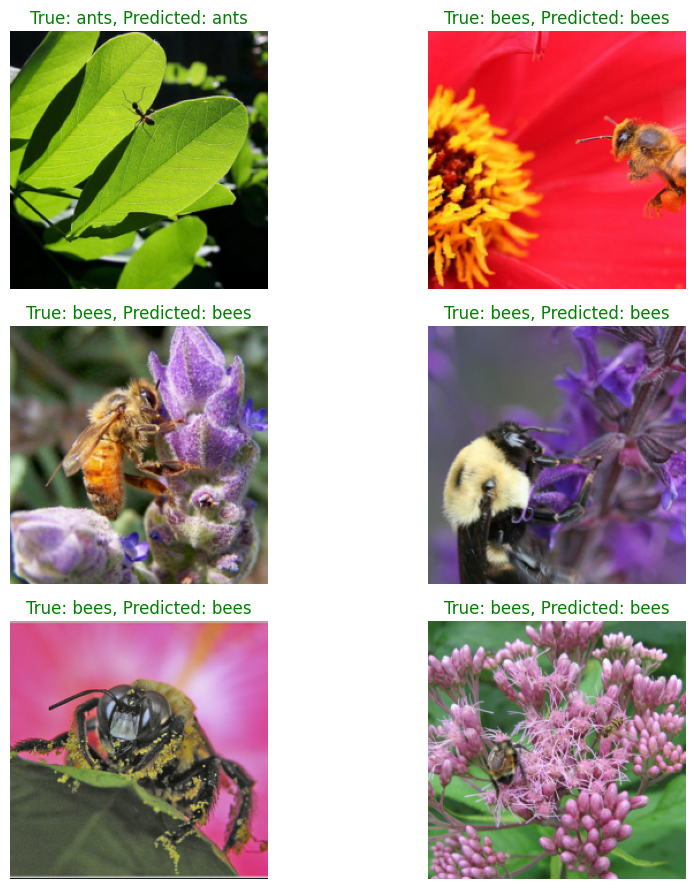

In [13]:
visualize_model(model_ft)

## 방법 2 : Pre-trained ConvNet을 weight 고정된 특징 추출기로 사용

- 미리 학습된 모델을 불러온 후 마지막의 **완전 연결층 만을 새로 작성**하되 마지막 계층을 제외한 **신경망의 모든 부분을 고정** (``requires_grad = False`` 로 설정)하여 ``backward()`` 중에 gradient가 계산되지 않도록 함

In [14]:
# 사전 학습된 ResNet-18 모델 로드 (PyTorch 0.13+ 신 가중치 API)
model_conv = torchvision.models.resnet18(weights=WEIGHTS)

# 모든 파라미터의 requires_grad = False 로 설정 → 가중치 고정 (feature extractor)
for param in model_conv.parameters():
    param.requires_grad = False

# 새로 정의할 fully-connected 레이어(fc) 의 입력 특징 수 추출
num_ftrs = model_conv.fc.in_features

# 출력층(fc) 을 이진 분류용으로 교체 (출력 클래스 수 = 2)
# 새로 생성한 fc 레이어의 파라미터는 기본적으로 requires_grad=True → 이 부분만 학습됨
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

# 손실 함수 설정
criterion = nn.CrossEntropyLoss()

# 옵티마이저: 전체가 아닌 fc 레이어의 파라미터만 최적화 대상
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# 학습률 스케줄러: 7 에폭마다 학습률을 0.1 배씩 감소
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)


### 훈련 및 평가

In [15]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=10)


Epoch 1/10
--------------------
Train Loss: 0.5847 Acc: 0.6967
Val Loss: 0.2246 Acc: 0.9281
새로운 최고 성능! 정확도: 0.9281

Epoch 2/10
--------------------
Train Loss: 0.6187 Acc: 0.7295
Val Loss: 0.1751 Acc: 0.9412
새로운 최고 성능! 정확도: 0.9412

Epoch 3/10
--------------------
Train Loss: 0.5317 Acc: 0.7336
Val Loss: 0.1890 Acc: 0.9477
새로운 최고 성능! 정확도: 0.9477

Epoch 4/10
--------------------
Train Loss: 0.5964 Acc: 0.7418
Val Loss: 0.1848 Acc: 0.9346

Epoch 5/10
--------------------
Train Loss: 0.7890 Acc: 0.7336
Val Loss: 0.2844 Acc: 0.8889

Epoch 6/10
--------------------
Train Loss: 0.4443 Acc: 0.7910
Val Loss: 0.2186 Acc: 0.9412

Epoch 7/10
--------------------
Train Loss: 0.5032 Acc: 0.7992
Val Loss: 0.1676 Acc: 0.9477

Epoch 8/10
--------------------
Train Loss: 0.3594 Acc: 0.8648
Val Loss: 0.1971 Acc: 0.9346

Epoch 9/10
--------------------
Train Loss: 0.3623 Acc: 0.8402
Val Loss: 0.1876 Acc: 0.9412

Epoch 10/10
--------------------
Train Loss: 0.2882 Acc: 0.8811
Val Loss: 0.1918 Acc: 0.9412


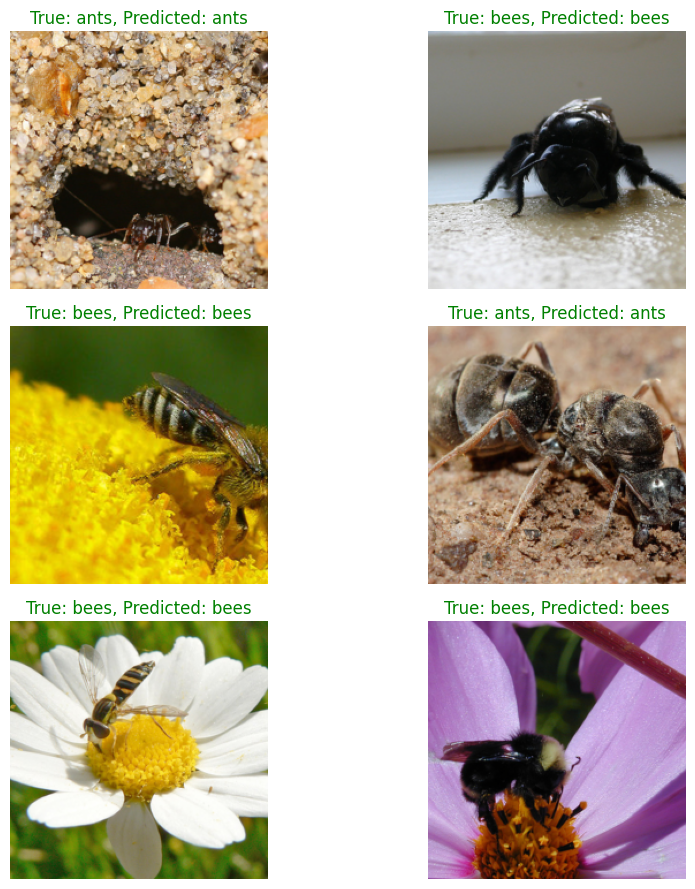

In [16]:
# 학습된 모델(model_conv)을 이용해 검증 데이터셋에서 예측 결과를 시각화
visualize_model(model_conv)